In [1]:
import pandas as pd
import fitz
import cv2
from io import BytesIO
from PIL import Image
import base64
from openai import OpenAI
from pydantic import BaseModel
import json
import numpy as np
import traceback
from typing import Optional
import io

import pandas as pd
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.styles import Alignment, Border, Side, Font

from blank_functions.forms.form_recognition import FormRecognition
from blank_functions.ui.ui_functions import get_pic_from_pdf, save_to_excel_local, get_correct_answers, postprocess_raw_output, check_answers, final_styling, extract_text_from_image, transform_json_to_dataframe
from blank_functions.ui.ui_functions import promt, prepare_cur_dict, reorder_cols

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# no limit columns for pandas
pd.set_option('display.max_columns', None)

c:\Users\zamko\Documents\mom_project\repo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import time

import os
# /Users/vladislav/Documents/mom_project_repo/streamlit-exam-form-app/notebooks/docling_test.ipynb
# os.chdir("C:\\Users\\zamko\\Documents\\mom_project\\repo\\notebooks")
# pdf_path = "./data/valid_format/valid_questions.pdf"
# answers_path = "./data/answers.xlsx"
# template_path = "./data/template_2.jpg"
# json_path = "./data/rows_data.json"

pdf_path = "C:/Users/zamko/Documents/mom_project/repo/data/valid_format/users_answears.pdf"
answers_path = "C:/Users/zamko/Documents/mom_project/repo/data/answers.xlsx"
template_path = "C:/Users/zamko/Documents/mom_project/repo/data/template_raw.jpg"
json_path = "C:/Users/zamko/Documents/mom_project/repo/data/rows_data_new_format.json"



pdf_bytes = open(pdf_path, 'rb').read()
pdf_document = fitz.open(stream=pdf_bytes, filetype="pdf")
num_pages = pdf_document.page_count

answers_bytes = open(answers_path, 'rb').read()
answers = pd.read_excel(BytesIO(answers_bytes))

cur_version = 2

df_global = pd.DataFrame()
form_dict = {}
for i in range(0, num_pages):
    cur_pic = get_pic_from_pdf(pdf_bytes, i, zoom=6.0)
    form = FormRecognition(
        image = cur_pic,
        template_path = template_path,
        json_path = json_path,
        answers = answers,
        version = cur_version)
    form = form.run_pipeline()
    cur_dict = prepare_cur_dict(form)
    df_current = transform_json_to_dataframe(cur_dict)
    df_global = pd.concat([df_global, df_current]).reset_index(drop=True)
    form_dict[i] = form

correct_answers = get_correct_answers(answers_bytes)
df_global_processed = postprocess_raw_output(df_global, correct_answers, cur_version)
df_global_answers = check_answers(df_global_processed)
df_global_styled = final_styling(df_global_answers)
df_global_styled = reorder_cols(df_global_styled)
save_to_excel_local(df_global_styled, form_dict)


C:\Users\zamko\Documents\mom_project\repo\blank_functions\ui\ui_functions.py:177: FutureWarning: Passing bytes to 'read_excel' is deprecated and will be removed in a future version. To read from a byte string, wrap it in a `BytesIO` object.
  correct_answers = pd.read_excel(correct_answers_path)


In [3]:
save_to_excel_local(df_global_styled, form_dict)


In [3]:
def postprocess_raw_output(df_global_fin, correct_answers, version):

    df_global_fin['Вариант'] = version

    df_global_fin['Дата'] = df_global_fin['Дата'].str.upper()
    df_global_fin['Вариант'] = df_global_fin['Вариант'].astype(int)
    df_global_fin['Вариант'] = df_global_fin['Вариант'].astype(str)
    for i in range(1, 11):
        df_global_fin[f'Задание {i}'] = df_global_fin[f'Задание {i}'].replace(',', '.', regex=True)
        df_global_fin[f'Задание {i}'] = df_global_fin[f'Задание {i}'].replace('', 'nan').astype(float)
        df_global_fin[f'Замена {i}'] = df_global_fin[f'Замена {i}'].replace(',', '.', regex=True)
        df_global_fin[f'Замена {i}'] = df_global_fin[f'Замена {i}'].replace('', 'nan').astype(float)
    for col in df_global_fin.columns:
        df_global_fin[col] = df_global_fin[col].astype(str)

    total_df = pd.merge(df_global_fin, correct_answers, on="Вариант", how="left")

    return total_df

correct_answers = get_correct_answers(answers_bytes)
df_global_processed = postprocess_raw_output(df_global, correct_answers, cur_version)
df_global_answers = check_answers(df_global_processed)
df_global_styled = final_styling(df_global_answers)
df_global_styled = reorder_cols(df_global_styled)
save_to_excel_local(df_global_styled, form_dict)

C:\Users\zamko\Documents\mom_project\repo\blank_functions\ui\ui_functions.py:177: FutureWarning: Passing bytes to 'read_excel' is deprecated and will be removed in a future version. To read from a byte string, wrap it in a `BytesIO` object.
  correct_answers = pd.read_excel(correct_answers_path)


ValueError: could not convert string to float: '.-.75'

C:\Users\zamko\AppData\Local\Temp\ipykernel_28540\1457861904.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(binary)
c:\Users\zamko\Documents\mom_project\repo\.venv\Lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)
C:\Users\zamko\AppData\Local\Temp\ipykernel_28540\1457861904.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


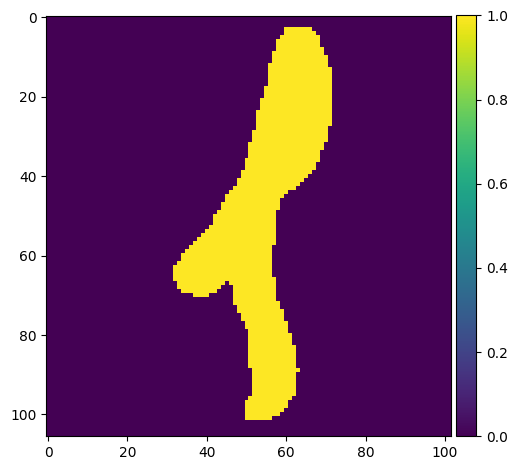

In [62]:
from skimage import io, filters
from skimage.color import rgb2gray

img = io.imread("image.jpg", as_gray=True)
threshold = filters.threshold_otsu(img)  # Автоматический порог
binary = img > threshold  # Делаем маску
binary = binary.astype(np.int8)
io.imshow(binary)
io.show()

C:\Users\zamko\AppData\Local\Temp\ipykernel_28540\2505937810.py:48: UserWarning: threshold_otsu is expected to work correctly only for grayscale images; image shape (28, 28, 3) looks like that of an RGB image.
  threshold = filters.threshold_otsu(image)  # Автоматический порог


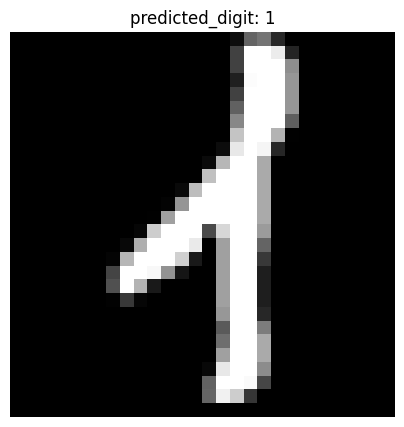

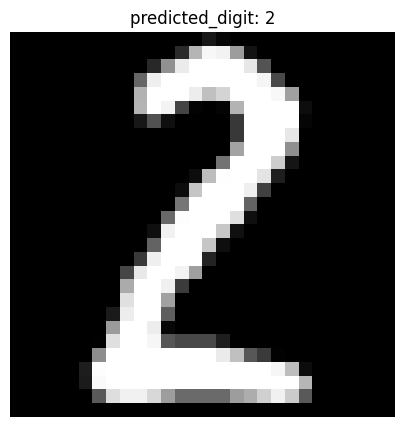

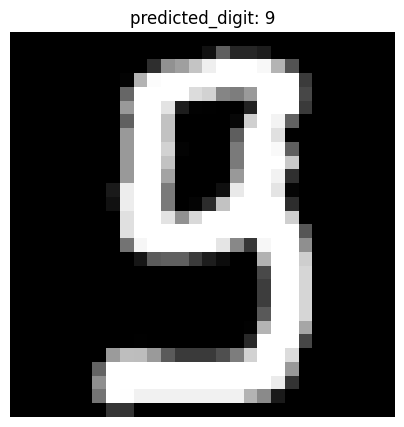

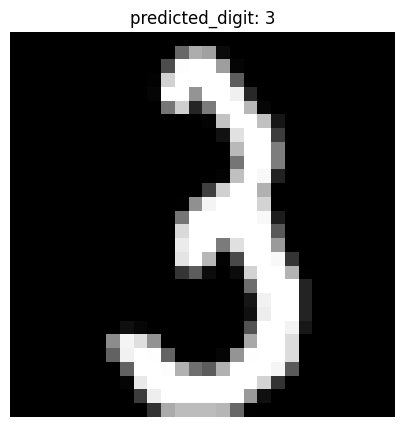

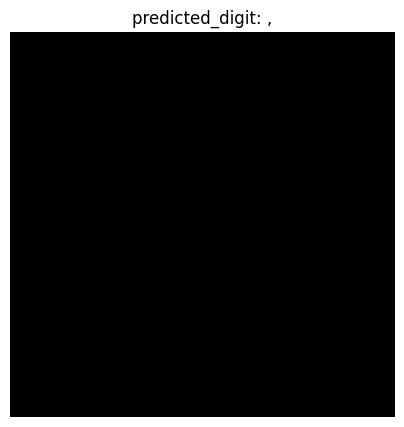

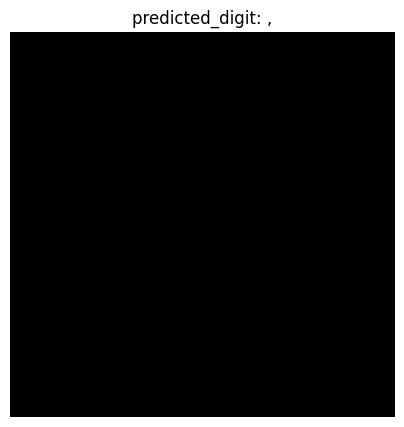

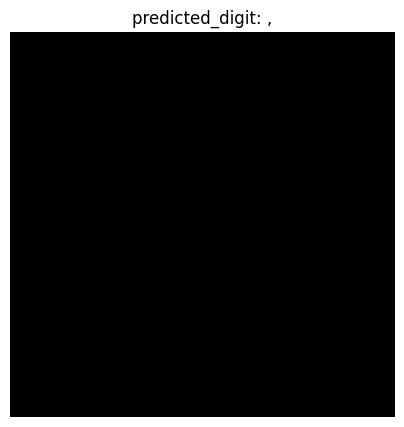

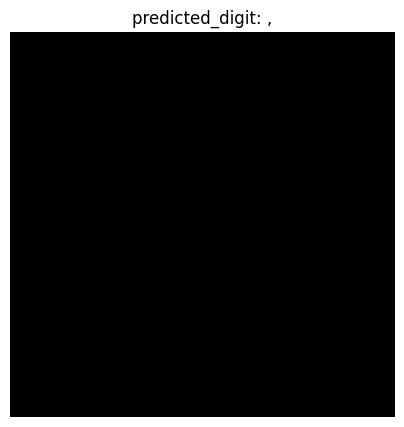

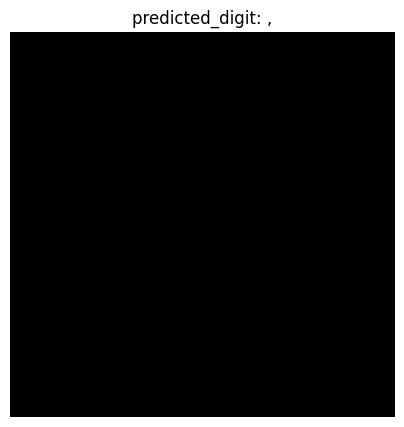

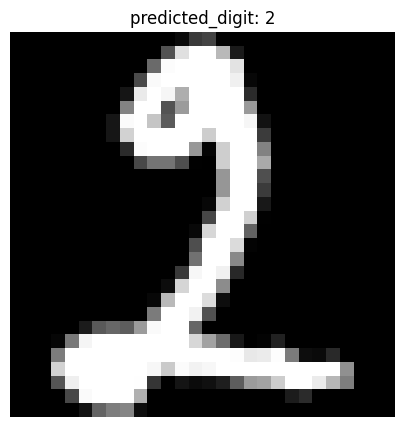

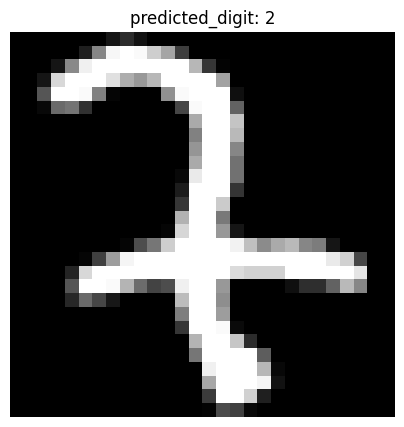

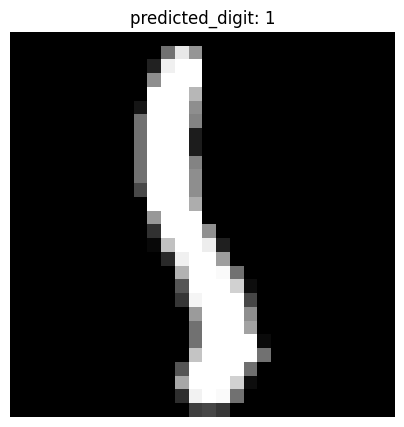

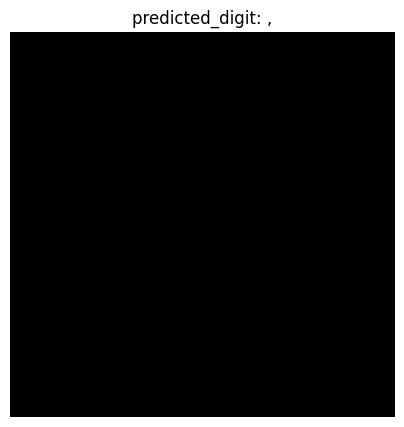

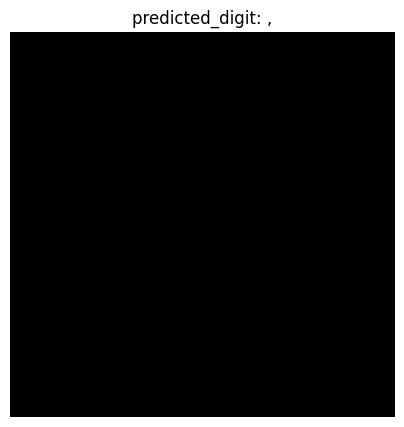

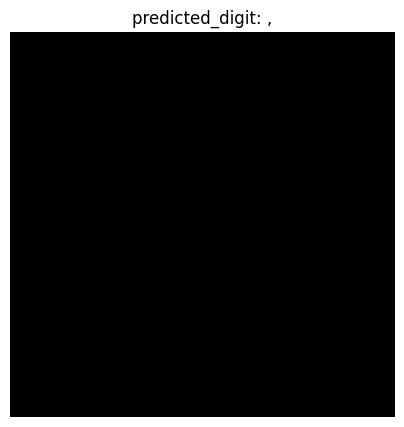

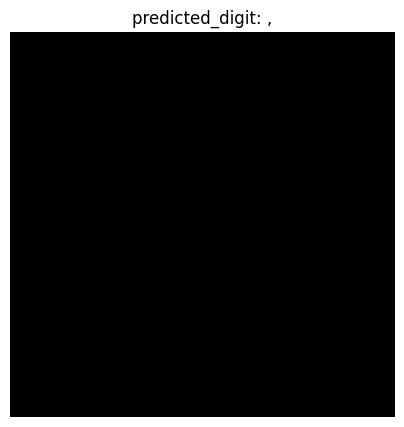

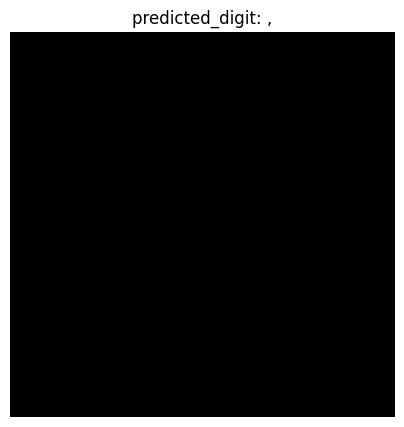

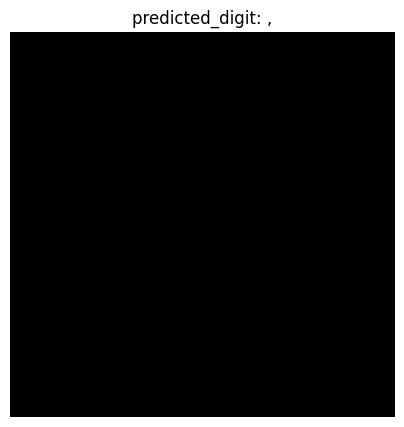

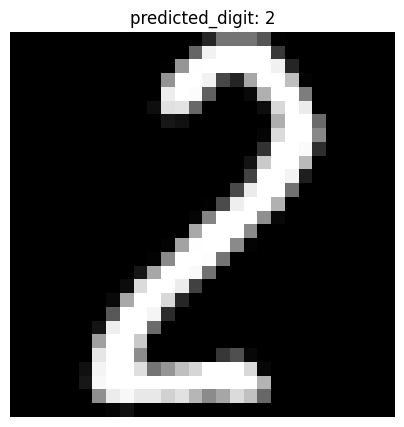

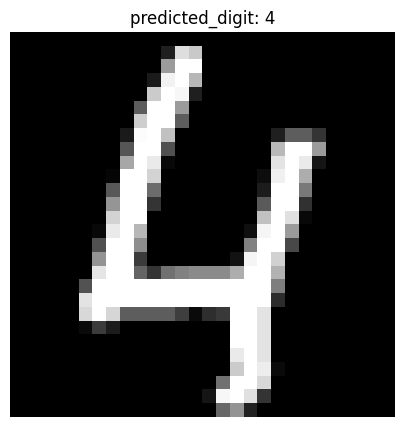

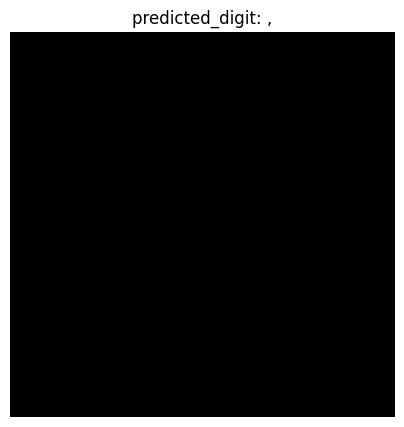

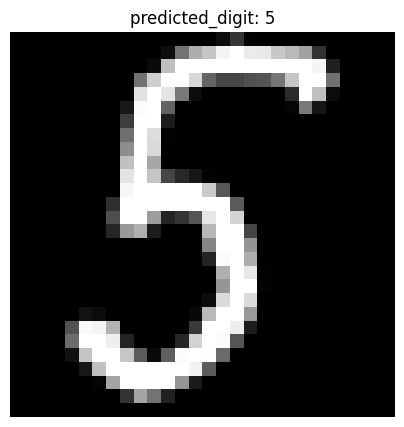

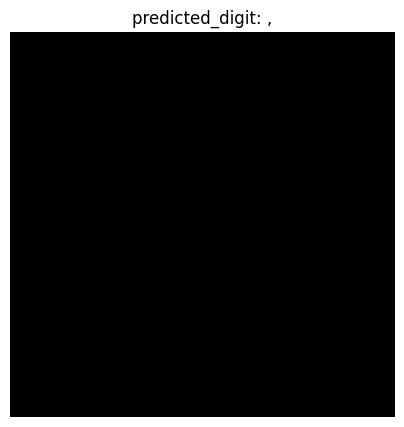

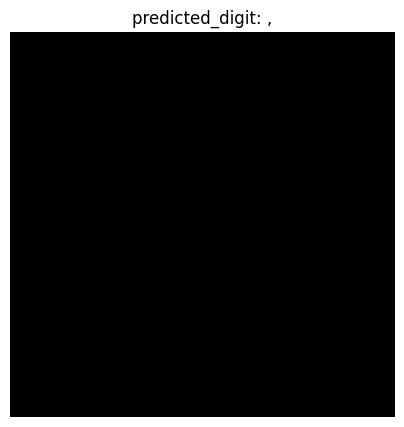

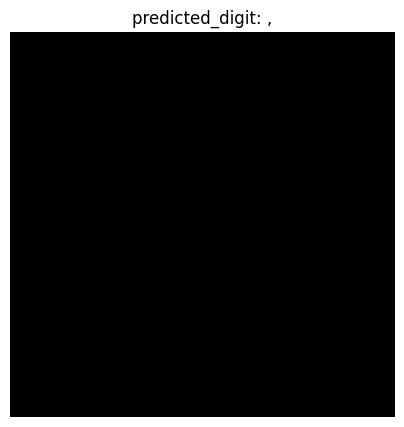

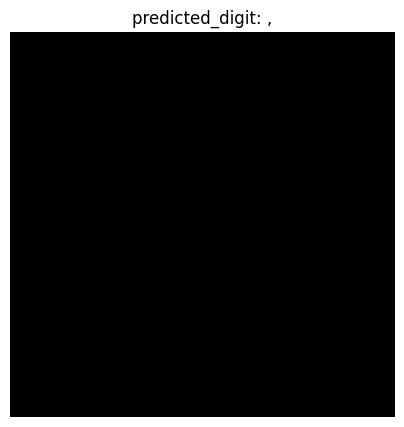

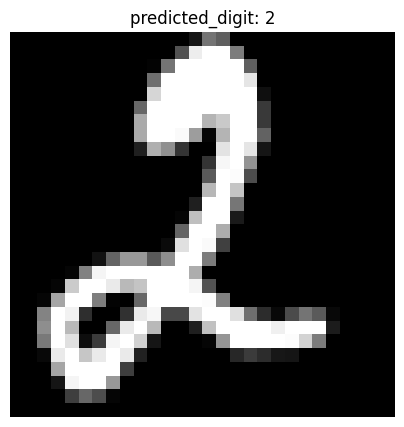

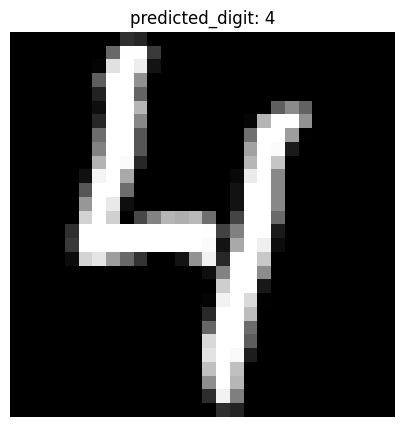

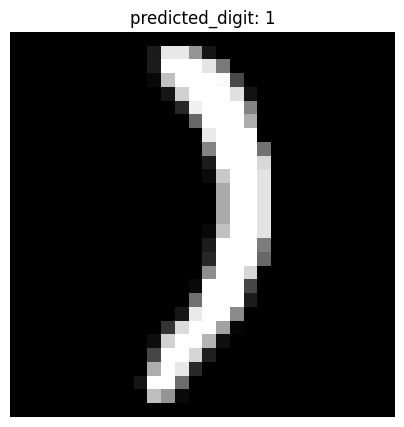

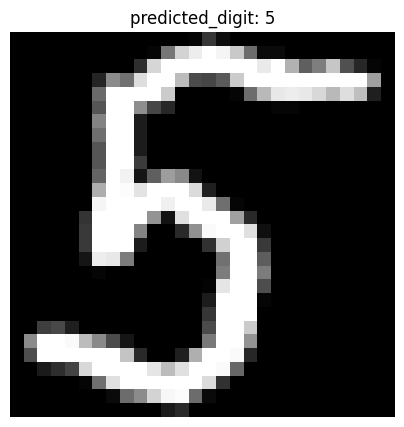

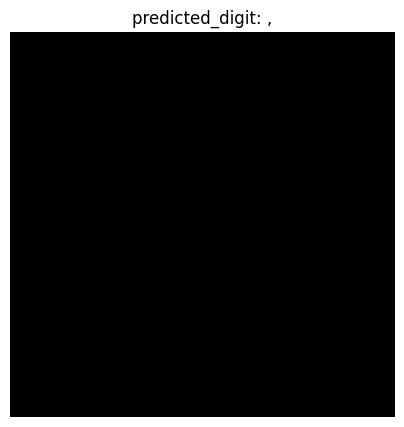

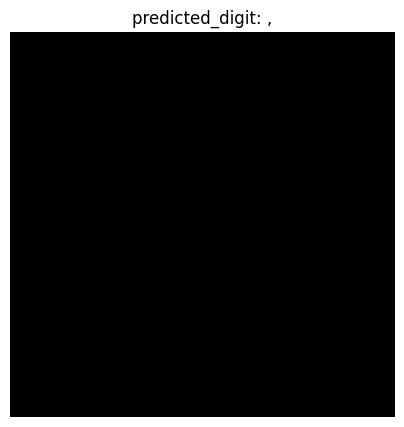

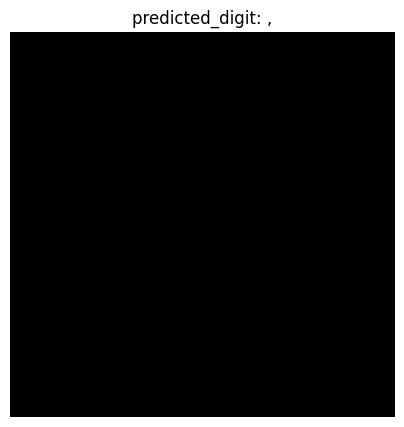

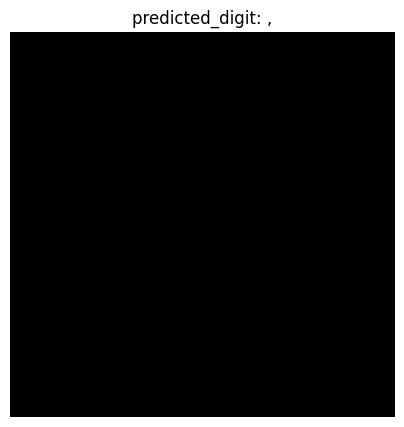

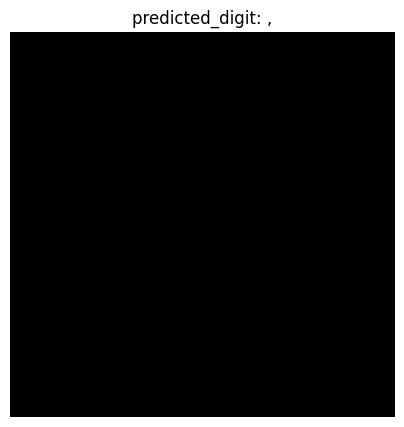

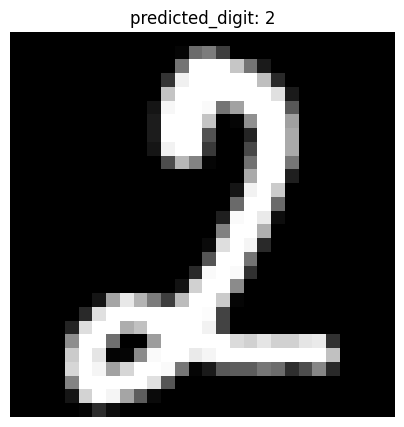

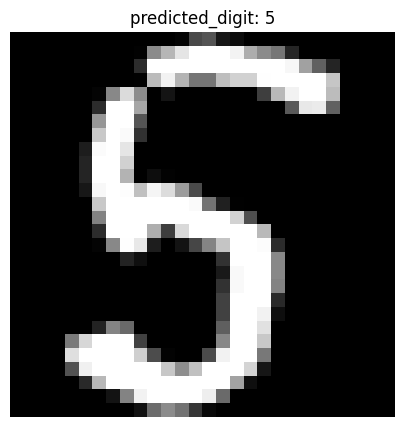

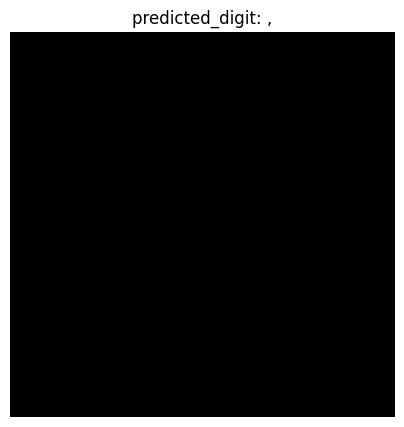

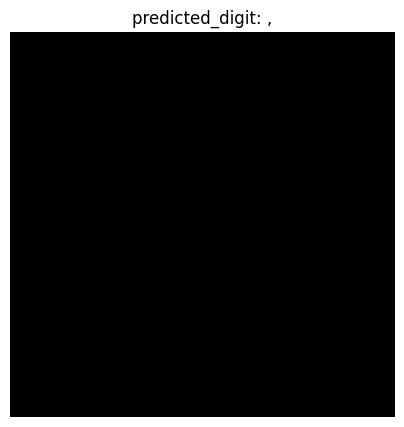

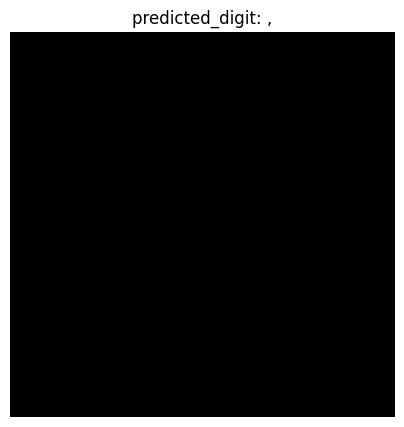

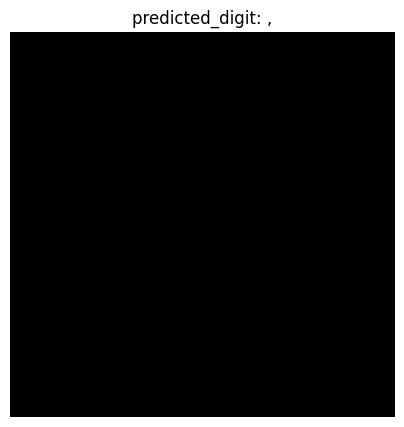

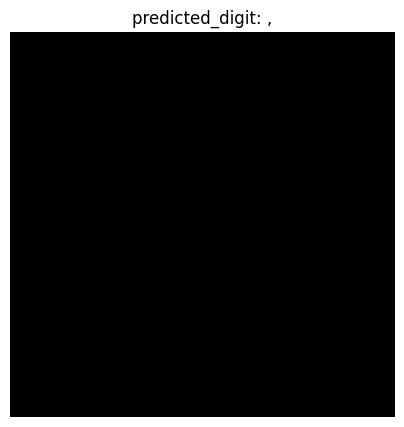

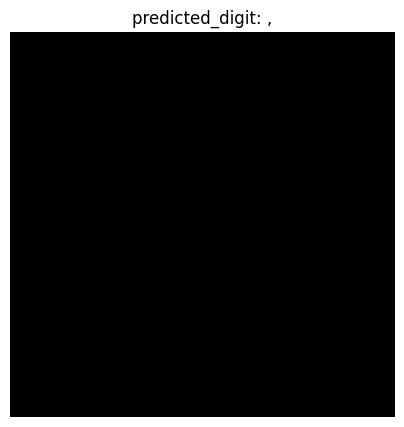

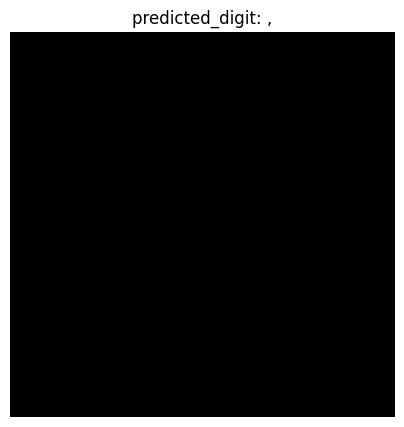

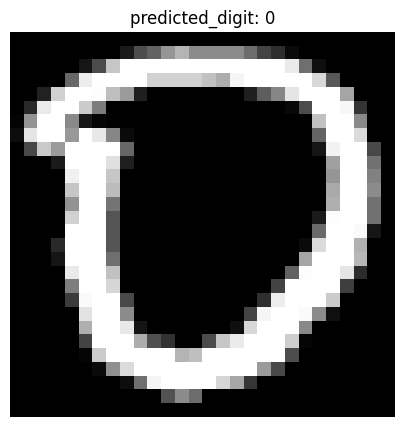

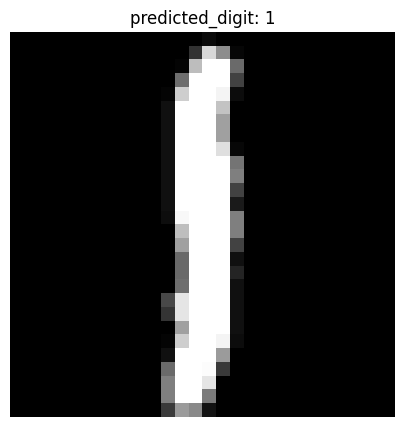

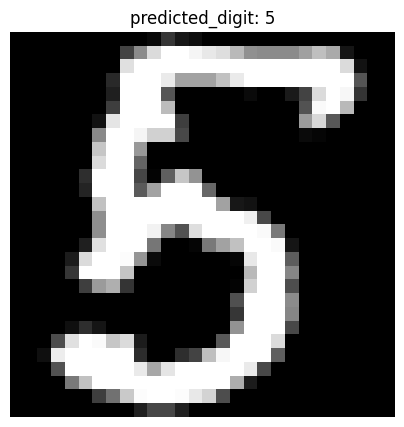

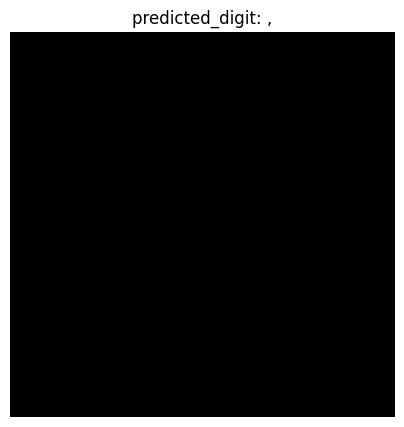

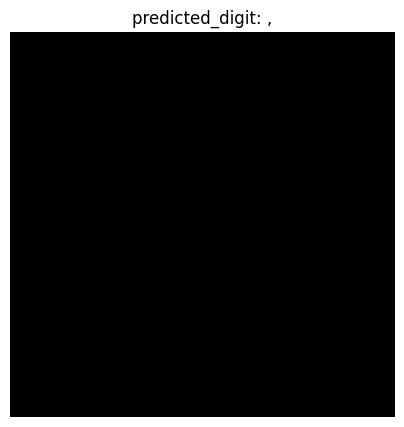

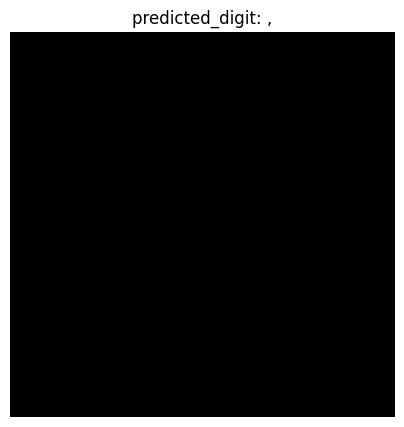

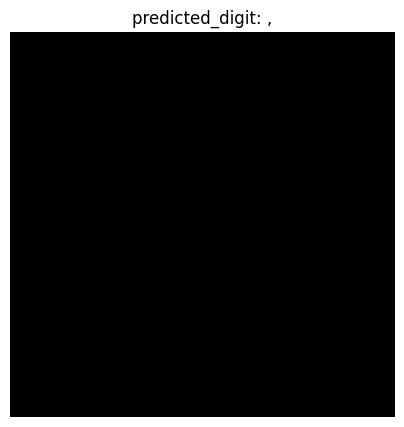

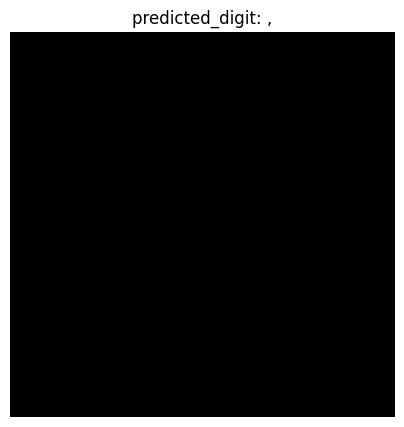

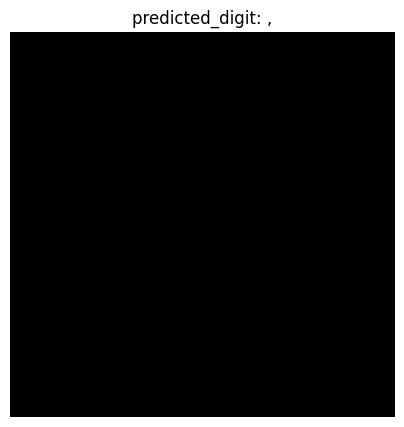

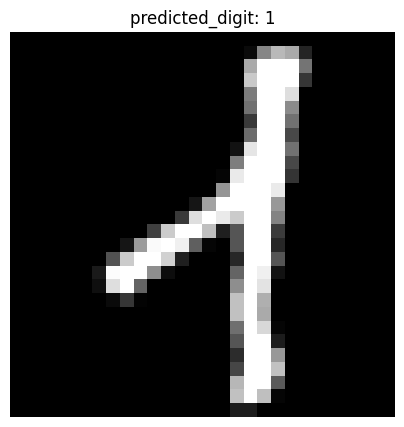

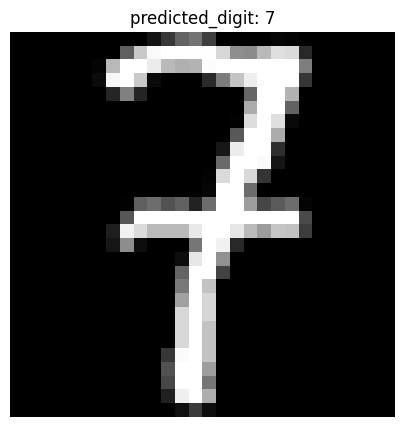

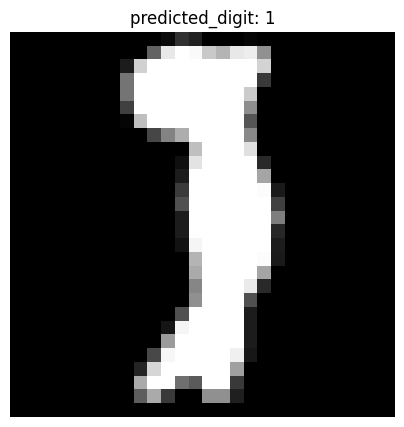

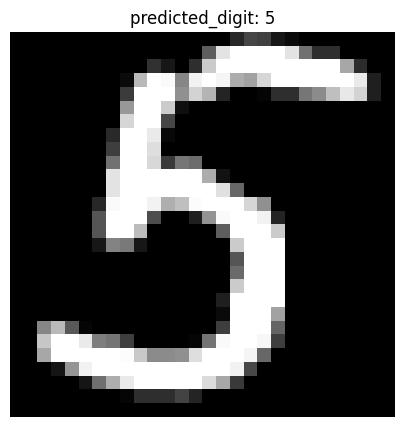

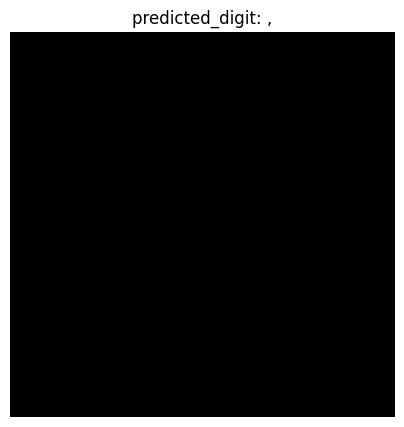

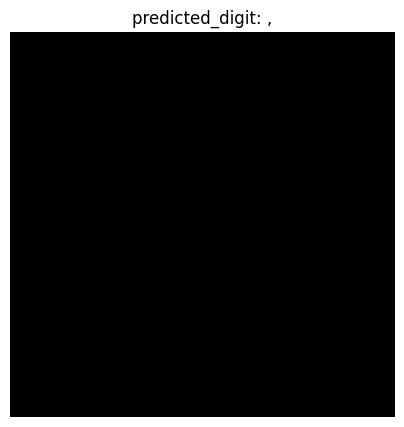

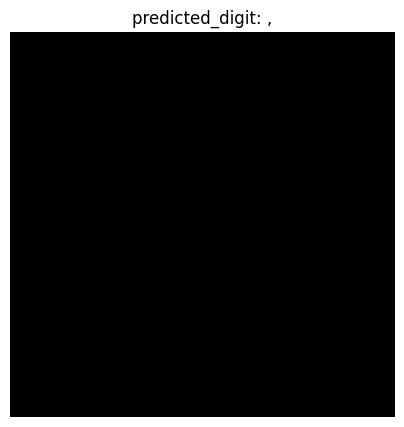

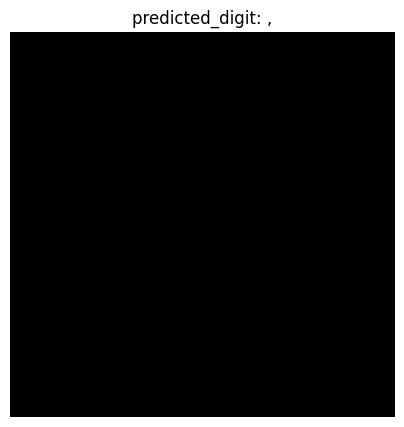

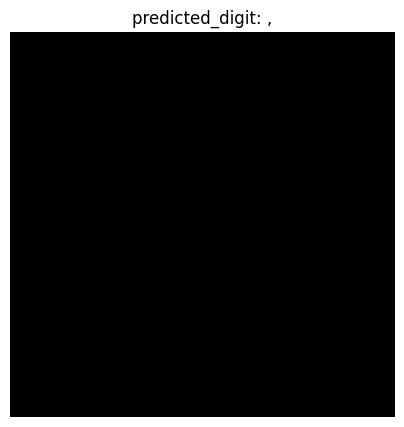

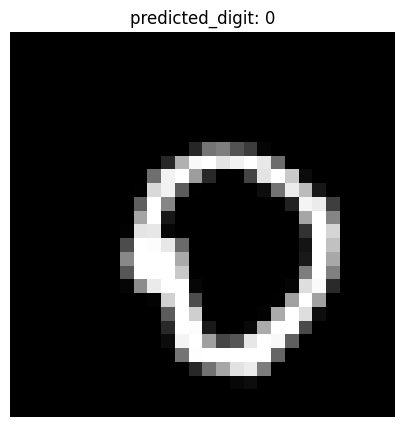

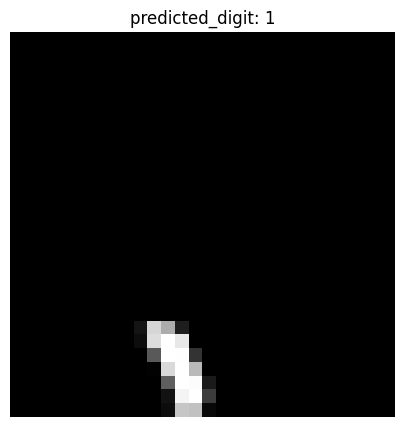

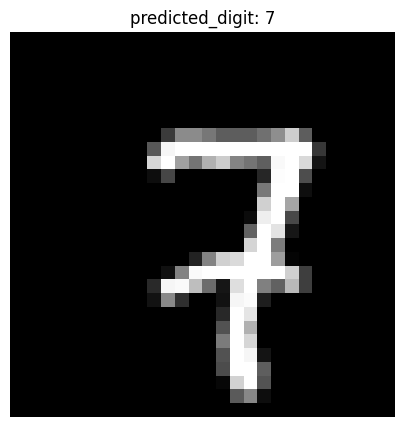

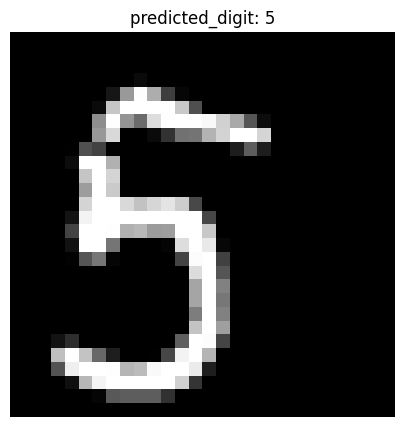

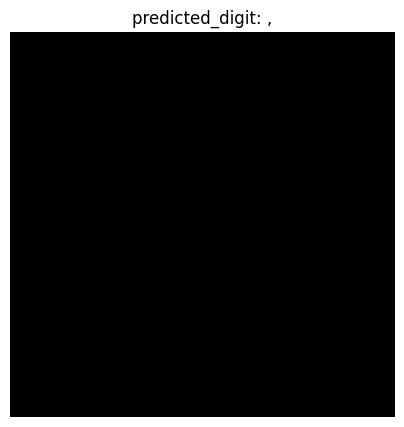

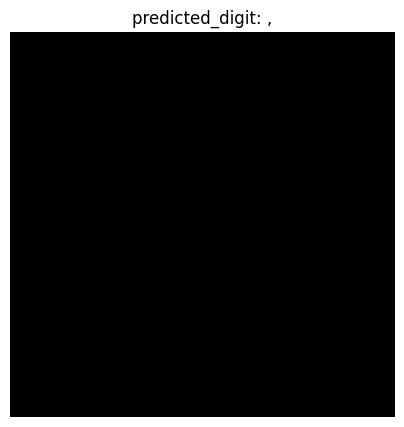

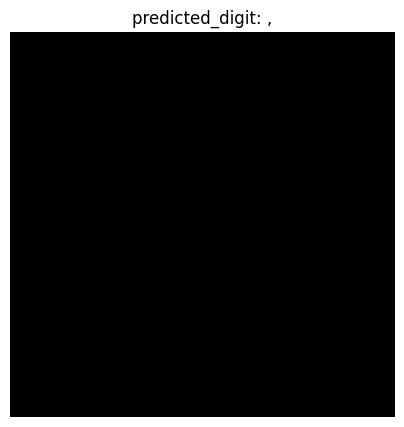

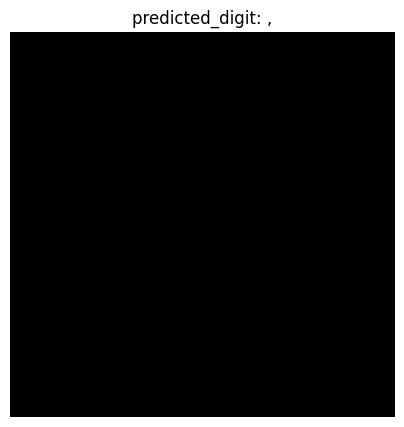

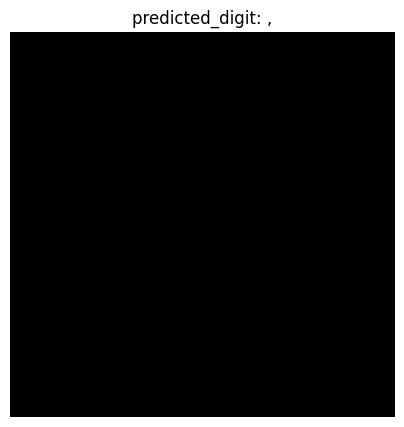

In [87]:
from transformers import CLIPProcessor, CLIPModel, CLIPVisionModel
from PIL import Image
import torch
import matplotlib.pyplot as plt
import cv2
import numpy as np

rows = [(16, form_dict[16].user_id),
(4, form_dict[4].answer1),
(2, form_dict[2].answer5),
(11, form_dict[11].answer5),
(12, form_dict[12].answer5),
(12, form_dict[12].answer8),
(11, form_dict[11].answer9),
(16, form_dict[16].answer10)]


string_to_digit = {
    'comma': ',',
    'minus': '-',
    'one': '1',
    'two': '2',
    'three': '3',
    'four': '4',
    'five': '5',
    'six': '6',
    'seven': '7',
    'eight': '8',
    'nine': '9',
    'zero': '0'
}

from torchvision import transforms
from PIL import Image


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vision_model = CLIPVisionModel.from_pretrained('tanganke/clip-vit-base-patch32_mnist').to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_model.vision_model.load_state_dict(vision_model.vision_model.state_dict())

# Load reference images
ref_images_dict = {name: cv2.resize(cv2.imread(f"C:/Users/zamko/Documents/mom_project/repo/data/ref_pics/{name}.png"), (28, 28), interpolation=cv2.INTER_AREA)
                   for name in ['comma', 'minus', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'zero']}

for key, image in ref_images_dict.items():
    threshold = filters.threshold_otsu(image)  # Автоматический порог
    binary = image > threshold  # Делаем маску
    binary_cv2 = (binary * 255).astype(np.uint8)
    # binary_cv2 = cv2.cvtColor(binary_cv2, cv2.COLOR_GRAY2BGR)
    ref_images_dict[key] = binary_cv2


ref_embeddings = {}
for key, image1 in ref_images_dict.items():
    image1_preprocess = processor(images=image1, return_tensors="pt")['pixel_values'].to(device)
    ref_embeddings[key] = clip_model.get_image_features(image1_preprocess)

def predict_digit(image):
    # image2 = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    image2 = image
    image2 = cv2.resize(image2, (28, 28), interpolation=cv2.INTER_AREA)
  
    
    image2_preprocess = processor(images=image2, return_tensors="pt")['pixel_values'].to(device)
    image2_embedding = clip_model.get_image_features(image2_preprocess)

    # Calculate similarity scores
    scores_dict = {key: torch.nn.functional.cosine_similarity(ref_embedding, image2_embedding)
                   for key, ref_embedding in ref_embeddings.items()}

    # Find the label with the highest similarity score
    scores_dict_max_name = max(scores_dict, key=scores_dict.get)
    predicted_digit = string_to_digit[scores_dict_max_name]

    # scores_dict_pretty = {key: round(value.item(), 3) for key, value in scores_dict.items()}
    # print(scores_dict_pretty)
    plt.figure(figsize=(5, 5))
    plt.imshow(image2)
    plt.axis('off')
    plt.title(f'predicted_digit: {predicted_digit}')
    plt.show()
    
    return predicted_digit, image2

from skimage import io, filters
from skimage.color import rgb2gray

for page_num, row in rows:
    for cell in row.cells:
        x, y, w, h = cell.x, cell.y, cell.w, cell.h
        image = form_dict[page_num].image[y:y+h, x:x+w]
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        image_raw = image.copy()

        img = image
        img = rgb2gray(img)
        threshold = filters.threshold_otsu(img)  # Автоматический порог
        binary = img > threshold  # Делаем маску
        binary_cv2 = (binary * 255).astype(np.uint8)
        binary_cv2 = cv2.cvtColor(binary_cv2, cv2.COLOR_GRAY2BGR)
        predicted_digit, image2 = predict_digit(binary_cv2)
        # plt.figure(figsize=(1, 1))
        # plt.imshow(binary_cv2)
        # plt.axis('off')
        # plt.show()




